# EDA: tickets.csv

This notebook performs exploratory data analysis on `data/hackathon-recover-x-cogito/tickets.csv`.
Sections:
- Import libraries
- Load and inspect data
- Missing values
- Data types and conversions
- Univariate analysis
- Bivariate analysis (correlations with train/val operations)
- Multivariate analysis
- Save processed data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
from IPython.display import display

## Load and Inspect Data
Load `tickets.csv` and show a quick summary (head, shape, dtypes).

In [2]:
file_path = "../data/hackathon-recover-x-cogito/tickets.csv"
tickets = pd.read_csv(file_path)
print('Shape:', tickets.shape)
tickets.head()

Shape: (369, 2)


,work_operation_cluster_code,n_tickets
0,68,5
1,204,1
2,315,2
3,138,8
4,340,23


## Missing Values
Identify and visualize missingness.

In [3]:
mv = tickets.isnull().sum().sort_values(ascending=False)
mv_percent = (tickets.isnull().mean()*100).sort_values(ascending=False)
missing_df = pd.concat([mv, mv_percent], axis=1)
missing_df.columns = ['missing_count','missing_percent']
missing_df[missing_df['missing_count']>0].head(30)

# plot top missing
top_miss = missing_df[missing_df['missing_count']>0].head(20)
if not top_miss.empty:
    plt.figure(figsize=(10,6))
    sns.barplot(x=top_miss['missing_percent'], y=top_miss.index, palette='plasma')
    plt.xlabel('Percent missing')
    plt.title('Top missing columns in tickets.csv')
    plt.show()
else:
    print('No missing values in tickets.csv')

No missing values in tickets.csv


## Data types & conversions
Try conversions and summarize types.

In [4]:
# Convert date-like columns
for c in tickets.columns:
    if 'date' in c.lower() or 'time' in c.lower():
        tickets[c] = pd.to_datetime(tickets[c], errors='coerce')

# Convert numeric-like object columns
for c in tickets.select_dtypes(include=['object']).columns:
    conv = pd.to_numeric(tickets[c].str.replace(',',''), errors='coerce')
    if conv.notnull().sum() >= len(tickets)*0.8:
        tickets[c] = conv
        print(f'Converted {c} to numeric')

# Show types after
tickets.dtypes.value_counts()

int64    2
Name: count, dtype: int64

## Univariate analysis
- Numeric: describe, histograms
- Categorical: top frequencies

Numeric: 2, Categorical: 0


,count,mean,std,min,25%,50%,75%,max
work_operation_cluster_code,369.0,195.149051,108.959466,-1.0,104.0,196.0,288.0,387.0
n_tickets,369.0,600.523035,4246.467560,1.0,13.0,65.0,230.0,68603.0


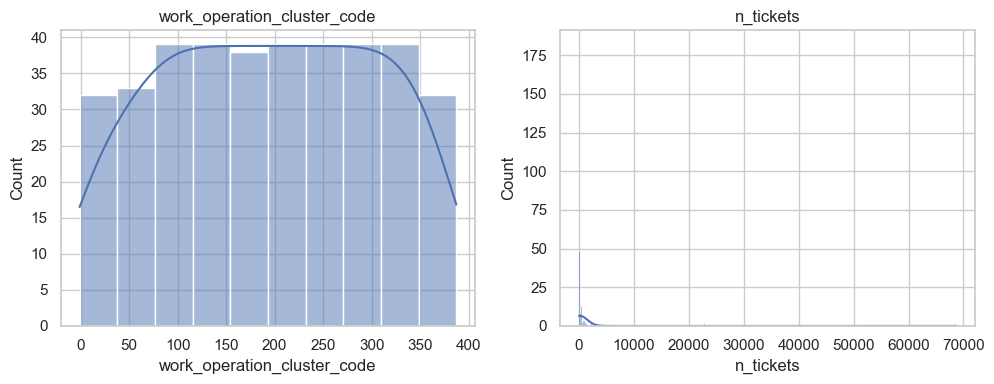

In [5]:
# Numeric and categorical columns
num_cols = tickets.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = tickets.select_dtypes(include=['object','category']).columns.tolist()

print(f"Numeric: {len(num_cols)}, Categorical: {len(cat_cols)}")

if num_cols:
    display(tickets[num_cols].describe().T)
    # Histograms
    plot_cols = num_cols[:12]
    n = len(plot_cols)
    ncols = 3
    nrows = (n + ncols - 1)//ncols
    plt.figure(figsize=(5*ncols, 4*nrows))
    for i,c in enumerate(plot_cols,1):
        plt.subplot(nrows, ncols, i)
        sns.histplot(tickets[c].dropna(), kde=True)
        plt.title(c)
    plt.tight_layout()
    plt.show()

if cat_cols:
    for c in cat_cols[:10]:
        vc = tickets[c].value_counts(dropna=False).head(20)
        print(f"\nTop for {c} (unique {tickets[c].nunique(dropna=False)}):")
        display(vc)
        plt.figure(figsize=(6, min(4, len(vc)*0.25+1)))
        sns.barplot(x=vc.values, y=vc.index, palette='magma')
        plt.show()

## Bivariate Analysis
Correlations between n_tickets and operation codes, and relationships with actual operation counts from train.csv.

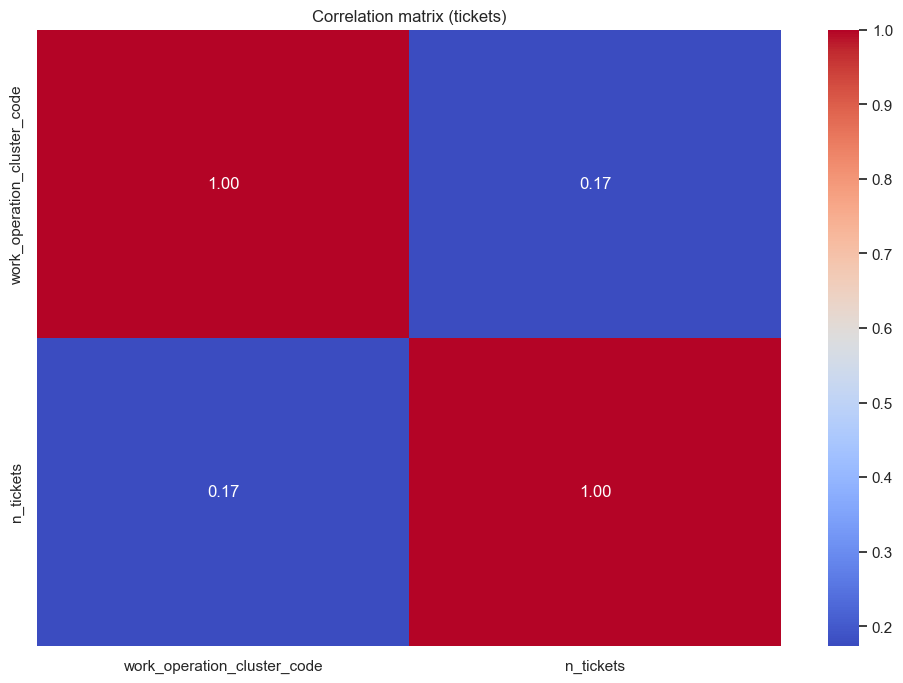

Merged tickets shape: (369, 3)


,work_operation_cluster_code,n_tickets,actual_n
0,68,5,11980.0
1,204,1,59020.0
2,315,2,25515.0
3,138,8,8457.0
4,340,23,2892.0


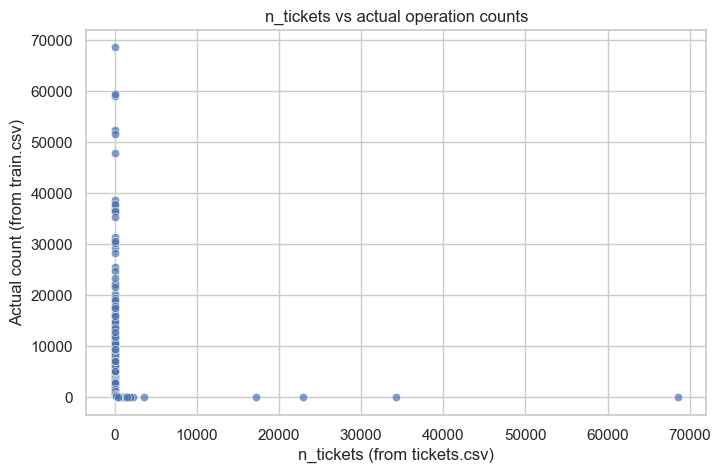

Correlation between n_tickets and actual counts:


,n_tickets,actual_n
n_tickets,1.000000,-0.071275
actual_n,-0.071275,1.000000


In [6]:
# Correlation heatmap for numeric columns
if num_cols:
    plt.figure(figsize=(12,8))
    sns.heatmap(tickets[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation matrix (tickets)')
    plt.show()

# Merge with train.csv to see actual operation counts vs n_tickets
import os
train_path = '../data/hackathon-recover-x-cogito/train.csv'
if os.path.exists(train_path):
    train = pd.read_csv(train_path)
    # Aggregate actual counts per cluster
    actual_counts = train.groupby('work_operation_cluster_code').size().reset_index(name='actual_n')
    # Merge with tickets
    merged_tickets = tickets.merge(actual_counts, on='work_operation_cluster_code', how='left')
    print('Merged tickets shape:', merged_tickets.shape)
    display(merged_tickets.head())

    # Scatter: n_tickets vs actual_n
    plt.figure(figsize=(8,5))
    sns.scatterplot(data=merged_tickets, x='n_tickets', y='actual_n', alpha=0.7)
    plt.title('n_tickets vs actual operation counts')
    plt.xlabel('n_tickets (from tickets.csv)')
    plt.ylabel('Actual count (from train.csv)')
    plt.show()

    # Correlation
    corr = merged_tickets[['n_tickets', 'actual_n']].corr()
    print('Correlation between n_tickets and actual counts:')
    display(corr)
else:
    print('train.csv not found')

## Multivariate Analysis
Pairplot and analysis of operation clusters by frequency.

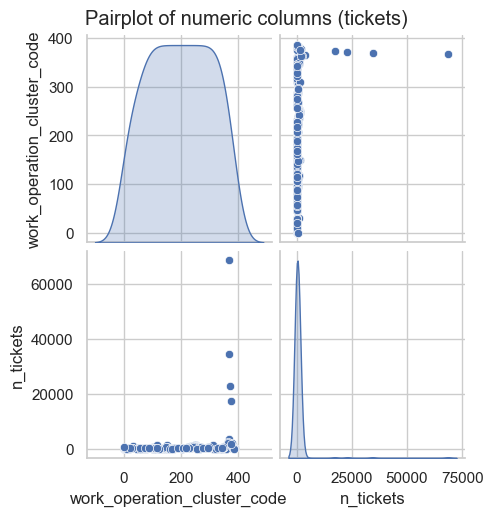

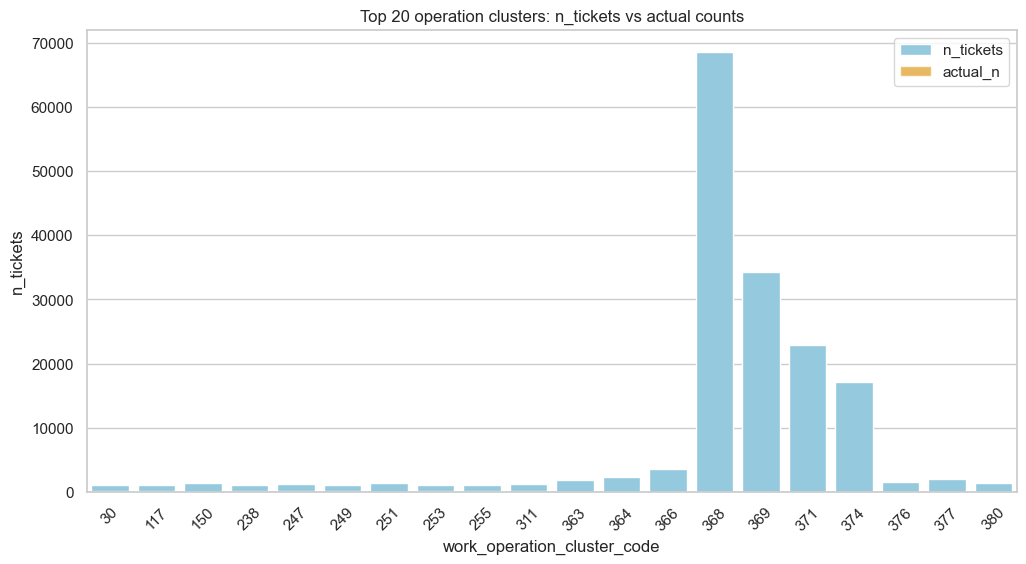

In [7]:
# Pairplot for numeric columns
if num_cols and len(num_cols) > 1:
    sns.pairplot(tickets[num_cols].dropna(), diag_kind='kde')
    plt.suptitle('Pairplot of numeric columns (tickets)', y=1.02)
    plt.show()

# If merged, analyze top operation clusters
if 'merged_tickets' in locals() and not merged_tickets.empty:
    top_clusters = merged_tickets.nlargest(20, 'n_tickets')
    plt.figure(figsize=(12,6))
    sns.barplot(data=top_clusters, x='work_operation_cluster_code', y='n_tickets', color='skyblue', label='n_tickets')
    sns.barplot(data=top_clusters, x='work_operation_cluster_code', y='actual_n', color='orange', alpha=0.7, label='actual_n')
    plt.title('Top 20 operation clusters: n_tickets vs actual counts')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

## Save Processed Data
Save cleaned tickets data for further analysis.

In [8]:
# Save processed tickets data
tickets.to_csv('../data/hackathon-recover-x-cogito/tickets_processed.csv', index=False)
print('Saved tickets_processed.csv')

Saved tickets_processed.csv
